# Side-Specific EPE Prediction Model

This notebook implements side-specific models for predicting Extraprostatic Extension (EPE) separately for the left (L) and right (P) sides of the prostate.

## Data Sources
- `processed_df_new.csv` - Main processed dataset
- `Studenciaki.xlsx` - Additional patient data
- `Studenciaki 2 safe.xlsx` - Supplementary dataset

## Targets
- **EPE L** - Left side Extraprostatic Extension
- **EPE P** - Right side Extraprostatic Extension


In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

pd.set_option('display.max_columns', None)
warnings.filterwarnings('ignore')

from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix, classification_report
from xgboost import XGBClassifier
import dalex as dx
from yellowbrick.classifier import DiscriminationThreshold

from unified_functions import (
    get_model_pipeline, 
    train_and_evaluate_model, 
    tune_hyperparameters, 
    plot_roc, 
    plot_confusion_matrix, 
    plot_discrimination_threshold, 
    plot_feature_importances,
    plot_distribution,
    discrimination_threshold
)


## 1. Data Loading
Loading all three datasets


In [2]:
# Load main processed dataset
df_main = pd.read_csv('../materials/processed_df_new.csv')
print(f"Main dataset shape: {df_main.shape}")
print(f"Columns: {df_main.columns.tolist()}")


Main dataset shape: (404, 31)
Columns: ['ID', 'wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI Pirads', 'MRI EPE', 'MRI EPE L', 'MRI EPE P', 'MRI SVI', 'MRI SVI L', 'MRI SVI P', 'MRI SIZE', 'Bx ISUP Grade P', 'Bx ISUP Grade L', 'ISUP RP', 'ISUP RP P', 'ISUP RP L', 'SM +', 'N +', 'EPE RP', 'EPE L RP', 'EPE P RP', 'SVI RP', 'SVI RP L', 'SVI RP P', 'TNM', 'EPE micro', 'EPE macro', 'EPE false_positive', 'Bx ISUP Grade']


In [4]:
# Load Studenciaki datasets
df_stud1 = pd.read_excel('../materials/Studenciaki.xlsx')
print(f"Studenciaki 1 shape: {df_stud1.shape}")

df_stud2 = pd.read_excel('../materials/Studenciaki 2 safe.xlsx')
# The first row contains headers
df_stud2.columns = df_stud2.iloc[0]
df_stud2 = df_stud2.iloc[1:].reset_index(drop=True)
print(f"Studenciaki 2 shape: {df_stud2.shape}")


Studenciaki 1 shape: (230, 151)
Studenciaki 2 shape: (77, 70)


In [5]:
# Explore main dataset - side-specific columns
side_cols = [col for col in df_main.columns if ' L' in col or ' P' in col or 'L ' in col or 'P ' in col]
print("Side-specific columns in main dataset:")
print(side_cols)


Side-specific columns in main dataset:
['MRI Pirads', 'MRI EPE L', 'MRI EPE P', 'MRI SVI L', 'MRI SVI P', 'Bx ISUP Grade P', 'Bx ISUP Grade L', 'ISUP RP', 'ISUP RP P', 'ISUP RP L', 'EPE L RP', 'EPE P RP', 'SVI RP L', 'SVI RP P', 'Bx ISUP Grade']


In [6]:
# Explore Studenciaki 2 - side-specific columns
side_cols_stud2 = [col for col in df_stud2.columns if str(col) != 'nan' and (' L' in str(col) or ' P' in str(col) or 'L ' in str(col) or 'P ' in str(col) or 'strona' in str(col).lower())]
print("Side-specific columns in Studenciaki 2:")
print(side_cols_stud2)


Side-specific columns in Studenciaki 2:
['zmiana nr 1\nmpMRI PIRADS\u2028zmiana (dominująca IL)', 'Lokalizacja zmiany nr 1 PL/PP', 'Maks wymiar IL w mpMRI', 'Zmiana nr 1\nISUP ', 'Gleason\u2028Strefy obwodowej IL ', 'ISUP \u2028strefy obwodowej IL', 'zmiana nr 2\nmpMRI PIRADS', 'Lokalizacja zmiany nr 2 PL/PP', 'Zmiana nr 2\nISUP ', 'zmiana nr 3\nmpMRI PIRADS', 'Lokalizacja zmiany nr 3 PL/PP', 'Zmiana nr 3\nISUP ', 'REGION IL\nISUP ', 'EPE który płat P/L/PL', 'ISUP post. Op', 'EPE strona P', 'EPE strona L', 'EPE strony P+L', 'SVI \u2028strona P', 'SVI strona\u2028L', 'SVI strony P+L']


## 2. Data Preparation for Side-Specific Model

We'll use the main dataset `processed_df_new.csv` as it already has well-structured side-specific columns:
- **MRI EPE L/P** - MRI findings for left/right side
- **MRI SVI L/P** - Seminal vesicle invasion on MRI for left/right side  
- **Bx ISUP Grade L/P** - Biopsy ISUP grade for left/right side
- **EPE L RP / EPE P RP** - Target: EPE on radical prostatectomy for left/right side


In [7]:
# Check available target columns
print("Target columns in main dataset:")
target_candidates = ['EPE L RP', 'EPE P RP', 'EPE RP', 'EPE micro', 'EPE macro']
for col in target_candidates:
    if col in df_main.columns:
        print(f"  {col}: {df_main[col].value_counts().to_dict()}")


Target columns in main dataset:
  EPE L RP: {0.0: 307, 1.0: 97}
  EPE P RP: {0.0: 311, 1.0: 93}
  EPE RP: {0.0: 273, 1.0: 131}
  EPE micro: {0.0: 311, 1.0: 93}
  EPE macro: {0.0: 366, 1.0: 38}


In [8]:
# Define feature columns for side-specific models

# Common features for both sides
numerical_cols_common = ['wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI SIZE']
categorical_cols_common = ['MRI Pirads', 'MRI EPE (naciek poza torebke)', 'MRI SVI (pecherzyki)']

# Left side specific features
numerical_cols_L = numerical_cols_common.copy()
categorical_cols_L = categorical_cols_common + ['MRI EPE L', 'MRI SVI L', 'Bx ISUP Grade L']

# Right side specific features
numerical_cols_P = numerical_cols_common.copy()
categorical_cols_P = categorical_cols_common + ['MRI EPE P', 'MRI SVI P', 'Bx ISUP Grade P']

# All side features (for combined side-aware model)
categorical_cols_all_sides = categorical_cols_common + ['MRI EPE L', 'MRI EPE P', 'MRI SVI L', 'MRI SVI P', 'Bx ISUP Grade L', 'Bx ISUP Grade P', 'Bx ISUP Grade']

print("Feature configuration:")
print(f"  Common numerical: {numerical_cols_common}")
print(f"  Left categorical: {categorical_cols_L}")
print(f"  Right categorical: {categorical_cols_P}")


Feature configuration:
  Common numerical: ['wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI SIZE']
  Left categorical: ['MRI Pirads', 'MRI EPE (naciek poza torebke)', 'MRI SVI (pecherzyki)', 'MRI EPE L', 'MRI SVI L', 'Bx ISUP Grade L']
  Right categorical: ['MRI Pirads', 'MRI EPE (naciek poza torebke)', 'MRI SVI (pecherzyki)', 'MRI EPE P', 'MRI SVI P', 'Bx ISUP Grade P']


In [9]:
# Prepare dataset - remove rows with missing targets
df = df_main.copy()

# Convert target columns to numeric
df['EPE L RP'] = pd.to_numeric(df['EPE L RP'], errors='coerce')
df['EPE P RP'] = pd.to_numeric(df['EPE P RP'], errors='coerce')
df['EPE RP'] = pd.to_numeric(df['EPE RP'], errors='coerce')

# Check for missing values in key columns
print("Missing values in target columns:")
print(f"  EPE L RP: {df['EPE L RP'].isna().sum()}")
print(f"  EPE P RP: {df['EPE P RP'].isna().sum()}")
print(f"  EPE RP: {df['EPE RP'].isna().sum()}")

# Drop rows with missing targets
df_clean = df.dropna(subset=['EPE L RP', 'EPE P RP', 'EPE RP'])
print(f"\nDataset size after dropping missing targets: {len(df_clean)}")


Missing values in target columns:
  EPE L RP: 0
  EPE P RP: 0
  EPE RP: 0

Dataset size after dropping missing targets: 404


## 3. Class Distribution Analysis


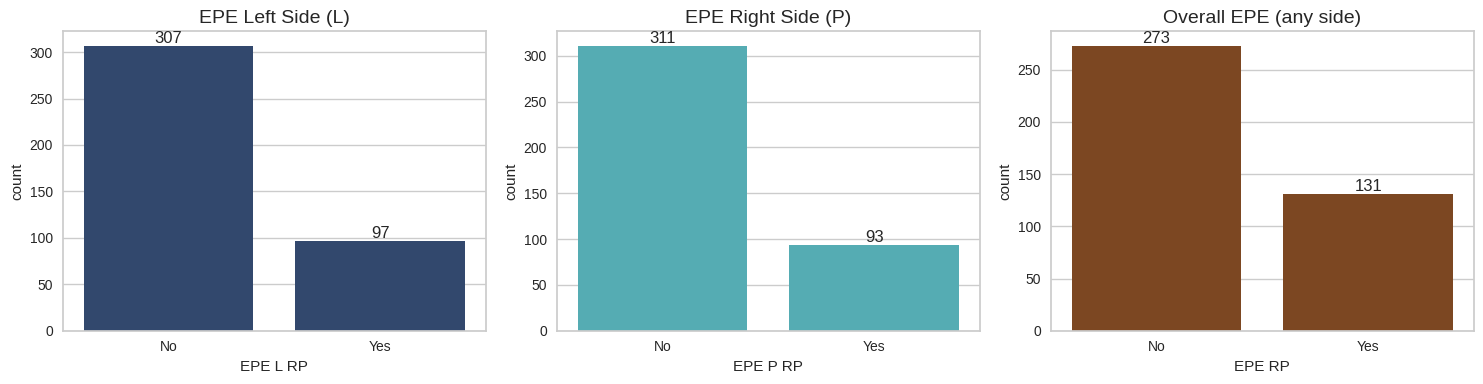

Class distribution summary:
  EPE L: {0.0: 307, 1.0: 97}
  EPE P: {0.0: 311, 1.0: 93}
  EPE (overall): {0.0: 273, 1.0: 131}


In [10]:
# Visualize class distributions for side-specific targets
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# EPE Left side
ax1 = sns.countplot(x='EPE L RP', data=df_clean, ax=axes[0], color='#284577')
ax1.bar_label(ax1.containers[0])
axes[0].set_title('EPE Left Side (L)', fontsize=14)
axes[0].set_xlabel('EPE L RP')
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['No', 'Yes'])

# EPE Right side
ax2 = sns.countplot(x='EPE P RP', data=df_clean, ax=axes[1], color='#46bac2')
ax2.bar_label(ax2.containers[0])
axes[1].set_title('EPE Right Side (P)', fontsize=14)
axes[1].set_xlabel('EPE P RP')
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['No', 'Yes'])

# Overall EPE
ax3 = sns.countplot(x='EPE RP', data=df_clean, ax=axes[2], color='#8B4513')
ax3.bar_label(ax3.containers[0])
axes[2].set_title('Overall EPE (any side)', fontsize=14)
axes[2].set_xlabel('EPE RP')
axes[2].set_xticks([0, 1])
axes[2].set_xticklabels(['No', 'Yes'])

plt.tight_layout()
plt.show()

print("Class distribution summary:")
print(f"  EPE L: {df_clean['EPE L RP'].value_counts().to_dict()}")
print(f"  EPE P: {df_clean['EPE P RP'].value_counts().to_dict()}")
print(f"  EPE (overall): {df_clean['EPE RP'].value_counts().to_dict()}")


In [11]:
# Analyze bilateral vs unilateral EPE
df_clean['EPE_bilateral'] = ((df_clean['EPE L RP'] == 1) & (df_clean['EPE P RP'] == 1)).astype(int)
df_clean['EPE_left_only'] = ((df_clean['EPE L RP'] == 1) & (df_clean['EPE P RP'] == 0)).astype(int)
df_clean['EPE_right_only'] = ((df_clean['EPE L RP'] == 0) & (df_clean['EPE P RP'] == 1)).astype(int)
df_clean['EPE_none'] = ((df_clean['EPE L RP'] == 0) & (df_clean['EPE P RP'] == 0)).astype(int)

print("EPE Distribution by Side:")
print(f"  No EPE: {df_clean['EPE_none'].sum()}")
print(f"  Left side only: {df_clean['EPE_left_only'].sum()}")
print(f"  Right side only: {df_clean['EPE_right_only'].sum()}")
print(f"  Bilateral (both sides): {df_clean['EPE_bilateral'].sum()}")


EPE Distribution by Side:
  No EPE: 273
  Left side only: 38
  Right side only: 34
  Bilateral (both sides): 59


## 4. Left Side EPE Model (EPE L)


In [12]:
# Prepare features for left side model
feature_cols_L = numerical_cols_L + categorical_cols_L

# Check for missing columns
missing_cols = [col for col in feature_cols_L if col not in df_clean.columns]
if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")
    feature_cols_L = [col for col in feature_cols_L if col in df_clean.columns]
    numerical_cols_L = [col for col in numerical_cols_L if col in df_clean.columns]
    categorical_cols_L = [col for col in categorical_cols_L if col in df_clean.columns]

X_L = df_clean[feature_cols_L]
y_L = df_clean['EPE L RP']

print(f"Left side model features: {feature_cols_L}")
print(f"X_L shape: {X_L.shape}")
print(f"y_L distribution: {y_L.value_counts().to_dict()}")


Left side model features: ['wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI SIZE', 'MRI Pirads', 'MRI EPE L', 'MRI SVI L', 'Bx ISUP Grade L']
X_L shape: (404, 9)
y_L distribution: {0.0: 307, 1.0: 97}


In [13]:
# Train Left Side EPE Model
print("="*60)
print("Training Left Side EPE Model")
print("="*60)

model_L = XGBClassifier(random_state=42)

# Use cross-validation for evaluation
y_true_L, y_pred_L, y_pred_probs_L, fpr_L, tpr_L, auc_L, trained_model_L, best_params_L, data_split_L = train_and_evaluate_model(
    model_L, X_L, y_L, 
    numerical_cols_L, categorical_cols_L, 
    n_folds=5, 
    tune_params=False
)


Training Left Side EPE Model
Training model with default hyperparameters...

Fold 0:
ROC AUC score: 0.7444821731748726

Fold 1:
ROC AUC score: 0.7258064516129031

Fold 2:
ROC AUC score: 0.6631147540983607

Fold 3:
ROC AUC score: 0.7040983606557377

Fold 4:
ROC AUC score: 0.7532355478861088

Total scores:
ROC AUC score: 0.7194331575942778




Left Side EPE Model Results:
ROC AUC: 0.7194


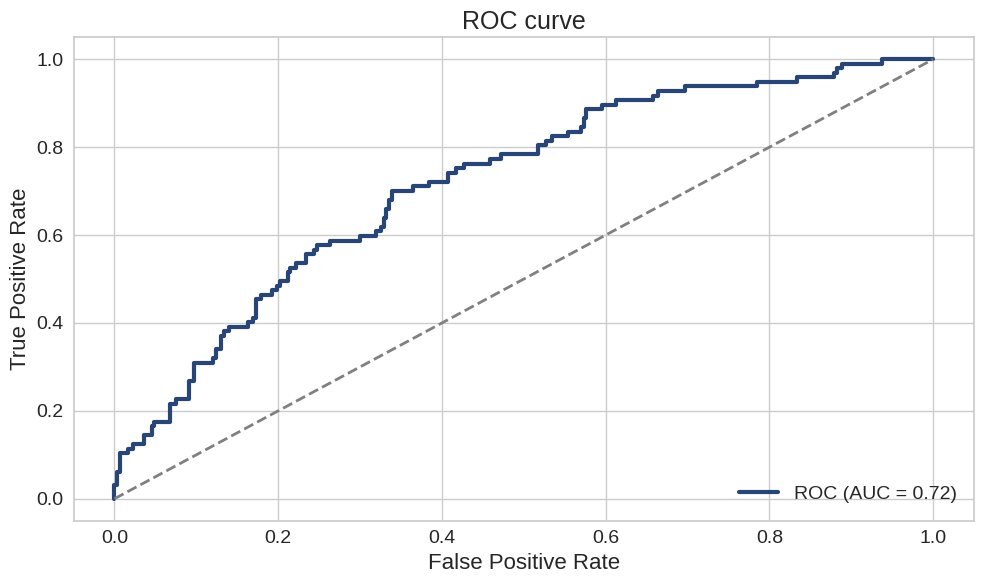

Optimal threshold (F1): 0.0828


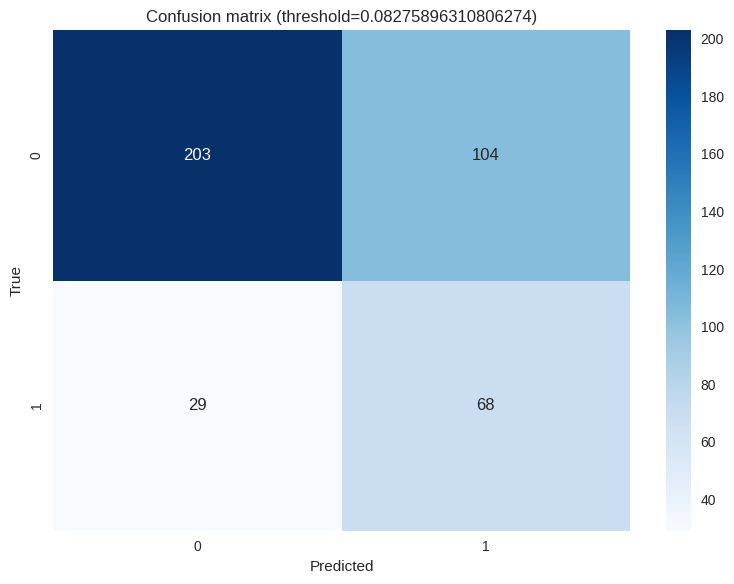

Sensitivity: 0.7010
Specificity: 0.6612
Accuracy: 0.6708


In [14]:
# Evaluate Left Side Model
print("\nLeft Side EPE Model Results:")
print(f"ROC AUC: {auc_L:.4f}")

# Plot ROC curve
plot_roc(fpr_L, tpr_L, auc_L)

# Find optimal threshold
optimal_threshold_L = discrimination_threshold(y_true_L, y_pred_probs_L, method='f1')
print(f"Optimal threshold (F1): {optimal_threshold_L:.4f}")

# Plot confusion matrix at optimal threshold
plot_confusion_matrix(y_true_L, y_pred_probs=y_pred_probs_L, threshold=optimal_threshold_L)


In [15]:
# Feature importance for Left Side Model
plot_feature_importances(trained_model_L, X_L, y_L, title="Feature Importance - Left Side EPE", max_vars=8)


Preparation of a new explainer is initiated

  -> data              : 404 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 404 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x7455a0c9e160> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 7.31e-05, mean = 0.228, max = 0.997
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.0118, max = 0.985
  -> model_info        : package sklearn

A new explainer has been created!


## 5. Right Side EPE Model (EPE P)


In [16]:
# Prepare features for right side model
feature_cols_P = numerical_cols_P + categorical_cols_P

# Check for missing columns
missing_cols = [col for col in feature_cols_P if col not in df_clean.columns]
if missing_cols:
    print(f"Warning: Missing columns: {missing_cols}")
    feature_cols_P = [col for col in feature_cols_P if col in df_clean.columns]
    numerical_cols_P = [col for col in numerical_cols_P if col in df_clean.columns]
    categorical_cols_P = [col for col in categorical_cols_P if col in df_clean.columns]

X_P = df_clean[feature_cols_P]
y_P = df_clean['EPE P RP']

print(f"Right side model features: {feature_cols_P}")
print(f"X_P shape: {X_P.shape}")
print(f"y_P distribution: {y_P.value_counts().to_dict()}")


Right side model features: ['wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI SIZE', 'MRI Pirads', 'MRI EPE P', 'MRI SVI P', 'Bx ISUP Grade P']
X_P shape: (404, 9)
y_P distribution: {0.0: 311, 1.0: 93}


In [17]:
# Train Right Side EPE Model
print("="*60)
print("Training Right Side EPE Model")
print("="*60)

model_P = XGBClassifier(random_state=42)

# Use cross-validation for evaluation
y_true_P, y_pred_P, y_pred_probs_P, fpr_P, tpr_P, auc_P, trained_model_P, best_params_P, data_split_P = train_and_evaluate_model(
    model_P, X_P, y_P, 
    numerical_cols_P, categorical_cols_P, 
    n_folds=5, 
    tune_params=False
)


Training Right Side EPE Model
Training model with default hyperparameters...

Fold 0:
ROC AUC score: 0.6375661375661376

Fold 1:
ROC AUC score: 0.7716468590831917

Fold 2:
ROC AUC score: 0.5356536502546689

Fold 3:
ROC AUC score: 0.66553480475382

Fold 4:
ROC AUC score: 0.7051971326164874

Total scores:
ROC AUC score: 0.6600629256992706




Right Side EPE Model Results:
ROC AUC: 0.6601


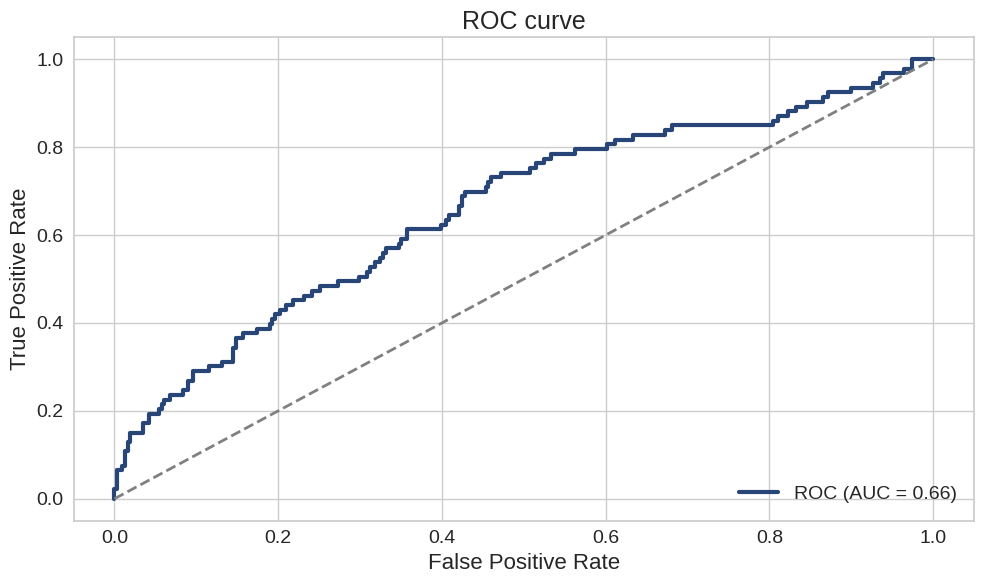

Optimal threshold (F1): 0.0367


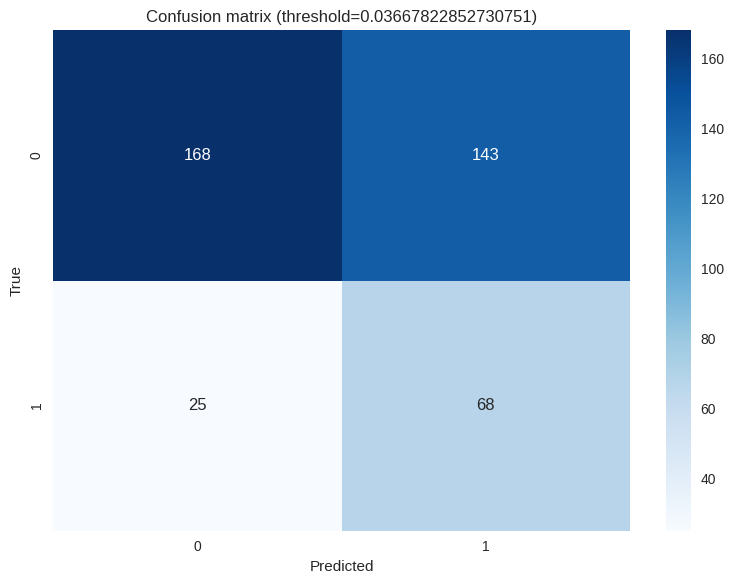

Sensitivity: 0.7312
Specificity: 0.5402
Accuracy: 0.5842


In [18]:
# Evaluate Right Side Model
print("\nRight Side EPE Model Results:")
print(f"ROC AUC: {auc_P:.4f}")

# Plot ROC curve
plot_roc(fpr_P, tpr_P, auc_P)

# Find optimal threshold
optimal_threshold_P = discrimination_threshold(y_true_P, y_pred_probs_P, method='f1')
print(f"Optimal threshold (F1): {optimal_threshold_P:.4f}")

# Plot confusion matrix at optimal threshold
plot_confusion_matrix(y_true_P, y_pred_probs=y_pred_probs_P, threshold=optimal_threshold_P)


In [19]:
# Feature importance for Right Side Model
plot_feature_importances(trained_model_P, X_P, y_P, title="Feature Importance - Right Side EPE", max_vars=8)


Preparation of a new explainer is initiated

  -> data              : 404 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 404 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x7455a0c9e160> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 0.000227, mean = 0.225, max = 0.999
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.966, mean = 0.00564, max = 1.0
  -> model_info        : package sklearn

A new explainer has been created!


## 6. Overall EPE Model (for comparison)


In [20]:
# Prepare features for overall EPE model
feature_cols_all = numerical_cols_common + categorical_cols_all_sides

# Check for missing columns
feature_cols_all = [col for col in feature_cols_all if col in df_clean.columns]
numerical_cols_all = [col for col in numerical_cols_common if col in df_clean.columns]
categorical_cols_all = [col for col in categorical_cols_all_sides if col in df_clean.columns]

X_all = df_clean[feature_cols_all]
y_all = df_clean['EPE RP']

print(f"Overall model features: {feature_cols_all}")
print(f"X_all shape: {X_all.shape}")
print(f"y_all distribution: {y_all.value_counts().to_dict()}")


Overall model features: ['wiek', 'PSA', 'PSAdensity', 'MRI vol', 'MRI SIZE', 'MRI Pirads', 'MRI EPE L', 'MRI EPE P', 'MRI SVI L', 'MRI SVI P', 'Bx ISUP Grade L', 'Bx ISUP Grade P', 'Bx ISUP Grade']
X_all shape: (404, 13)
y_all distribution: {0.0: 273, 1.0: 131}


In [23]:
# Train Overall EPE Model
print("="*60)
print("Training Overall EPE Model (for comparison)")
print("="*60)

model_all = XGBClassifier(random_state=42)

# Use cross-validation for evaluation
y_true_all, y_pred_all, y_pred_probs_all, fpr_all, tpr_all, auc_all, trained_model_all, best_params_all, data_split_all = train_and_evaluate_model(
    model_all, X_all, y_all, 
    numerical_cols_all, categorical_cols_all, 
    n_folds=5, 
    tune_params=False
)


Training Overall EPE Model (for comparison)
Training model with default hyperparameters...

Fold 0:
ROC AUC score: 0.7377622377622378

Fold 1:
ROC AUC score: 0.7328671328671329

Fold 2:
ROC AUC score: 0.7041958041958042

Fold 3:
ROC AUC score: 0.7304526748971193

Fold 4:
ROC AUC score: 0.646011396011396

Total scores:
ROC AUC score: 0.7077706009003719




Overall EPE Model Results:
ROC AUC: 0.7078


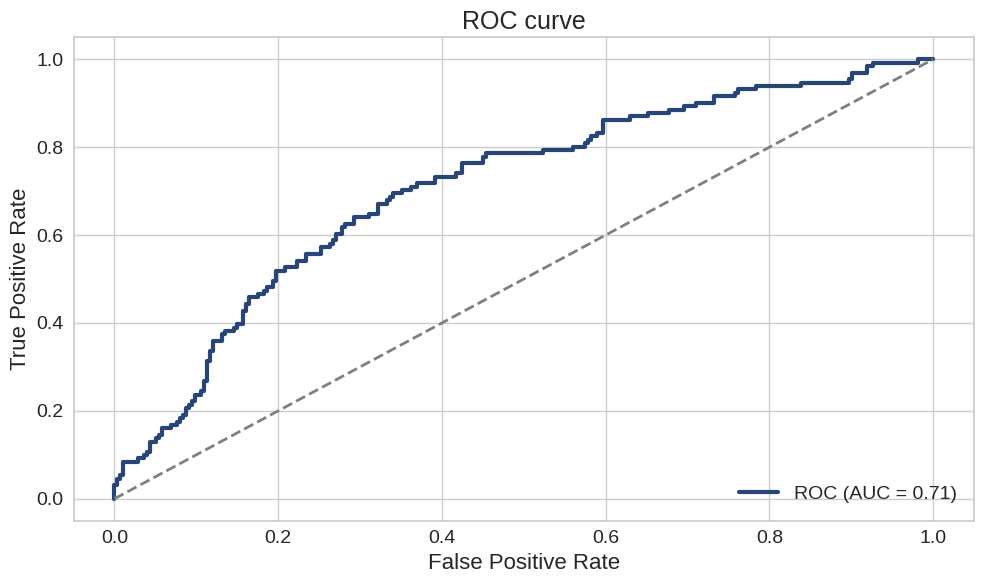

Optimal threshold (F1): 0.1547


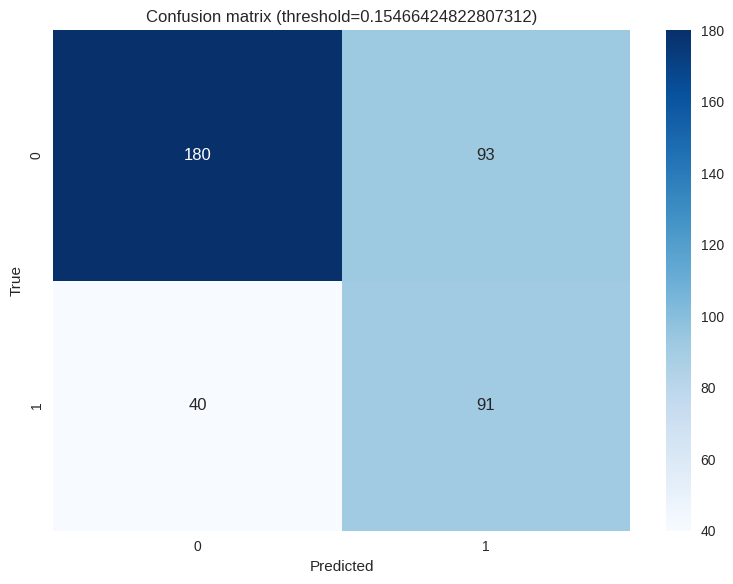

Sensitivity: 0.6947
Specificity: 0.6593
Accuracy: 0.6708


In [24]:
# Evaluate Overall Model
print("\nOverall EPE Model Results:")
print(f"ROC AUC: {auc_all:.4f}")

# Plot ROC curve
plot_roc(fpr_all, tpr_all, auc_all)

# Find optimal threshold
optimal_threshold_all = discrimination_threshold(y_true_all, y_pred_probs_all, method='f1')
print(f"Optimal threshold (F1): {optimal_threshold_all:.4f}")

# Plot confusion matrix at optimal threshold
plot_confusion_matrix(y_true_all, y_pred_probs=y_pred_probs_all, threshold=optimal_threshold_all)


## 7. Model Comparison


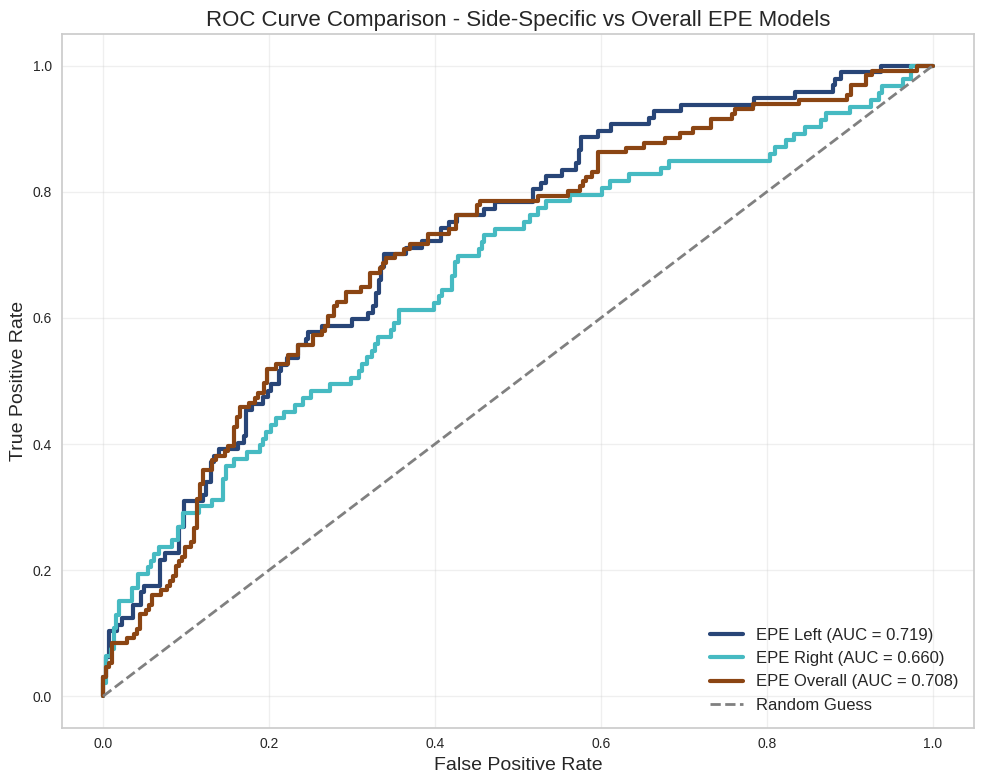

In [25]:
# Compare all three models on single ROC plot
plt.figure(figsize=(10, 8))

plt.plot(fpr_L, tpr_L, color='#284577', lw=3, label=f'EPE Left (AUC = {auc_L:.3f})')
plt.plot(fpr_P, tpr_P, color='#46bac2', lw=3, label=f'EPE Right (AUC = {auc_P:.3f})')
plt.plot(fpr_all, tpr_all, color='#8B4513', lw=3, label=f'EPE Overall (AUC = {auc_all:.3f})')
plt.plot([0, 1], [0, 1], color='gray', lw=2, linestyle='--', label='Random Guess')

plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('ROC Curve Comparison - Side-Specific vs Overall EPE Models', fontsize=16)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [29]:
# Summary table
summary_data = {
    'Model': ['EPE Left (L)', 'EPE Right (P)', 'EPE Overall'],
    'ROC AUC': [auc_L, auc_P, auc_all],
    'Optimal Threshold': [optimal_threshold_L, optimal_threshold_P, optimal_threshold_all],
    'Target Positive Rate': [
        y_L.mean(),
        y_P.mean(),
        y_all.mean()
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df['ROC AUC'] = summary_df['ROC AUC'].round(4)
summary_df['Optimal Threshold'] = summary_df['Optimal Threshold'].round(4)
summary_df['Target Positive Rate'] = (summary_df['Target Positive Rate'] * 100).round(2).astype(str) + '%'

print("\n" + "="*60)
print("MODEL COMPARISON SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))



MODEL COMPARISON SUMMARY
        Model  ROC AUC  Optimal Threshold Target Positive Rate
 EPE Left (L)   0.7194             0.0828               24.01%
EPE Right (P)   0.6601             0.0367               23.02%
  EPE Overall   0.7078             0.1547               32.43%


## 8. Hyperparameter Tuning (Optional)

Uncomment and run the cells below to perform hyperparameter tuning on the side-specific models.


In [27]:
# # Hyperparameter tuning for Left Side Model
# param_grid = {
#     'classifier__learning_rate': [0.05, 0.1, 0.2],
#     'classifier__n_estimators': [100, 200, 400],
#     'classifier__max_depth': [3, 5, 7],
#     'classifier__subsample': [0.8, 0.9, 1.0],
#     'classifier__colsample_bytree': [0.8, 0.9, 1.0],
# }

# model_L_tuned = XGBClassifier(random_state=42)

# y_true_L_t, y_pred_L_t, y_pred_probs_L_t, fpr_L_t, tpr_L_t, auc_L_t, trained_model_L_t, best_params_L_t, _ = train_and_evaluate_model(
#     model_L_tuned, X_L, y_L, 
#     numerical_cols_L, categorical_cols_L, 
#     n_folds=5, 
#     tune_params=True,
#     param_grid=param_grid,
#     tuning_scoring='roc_auc'
# )

# print(f"\nTuned Left Side Model AUC: {auc_L_t:.4f}")
# print(f"Best parameters: {best_params_L_t}")


In [28]:
# # Hyperparameter tuning for Right Side Model
# model_P_tuned = XGBClassifier(random_state=42)

# y_true_P_t, y_pred_P_t, y_pred_probs_P_t, fpr_P_t, tpr_P_t, auc_P_t, trained_model_P_t, best_params_P_t, _ = train_and_evaluate_model(
#     model_P_tuned, X_P, y_P, 
#     numerical_cols_P, categorical_cols_P, 
#     n_folds=5, 
#     tune_params=True,
#     param_grid=param_grid,
#     tuning_scoring='roc_auc'
# )

# print(f"\nTuned Right Side Model AUC: {auc_P_t:.4f}")
# print(f"Best parameters: {best_params_P_t}")


## 9. Conclusions

This notebook demonstrates side-specific EPE prediction models.

### Key Findings:
1. **Side-specific features** (MRI EPE L/P, MRI SVI L/P, Bx ISUP Grade L/P) allow for targeted prediction of EPE on each prostate side
2. **Model performance** can be compared between left side, right side, and overall EPE predictions
3. **Clinical utility**: Side-specific models may help surgeons in planning nerve-sparing approaches based on predicted EPE location

### Next Steps:
- Validate models on external datasets
- Compare with MSKCC nomograms for side-specific prediction
- Investigate features that differ in importance between left and right side models
- Consider integrating additional data from Studenciaki datasets for enhanced predictions


In [30]:
# Feature importance for Left Side Model
plot_feature_importances(trained_model_L, X_L, y_L, title="Feature Importance - Left Side EPE", max_vars=8)


Preparation of a new explainer is initiated

  -> data              : 404 rows 9 cols
  -> target variable   : Parameter 'y' was a pandas.Series. Converted to a numpy.ndarray.
  -> target variable   : 404 values
  -> model_class       : xgboost.sklearn.XGBClassifier (default)
  -> label             : Not specified, model's class short name will be used. (default)
  -> predict function  : <function yhat_proba_default at 0x7455a0c9e160> will be used (default)
  -> predict function  : Accepts only pandas.DataFrame, numpy.ndarray causes problems.
  -> predicted values  : min = 7.31e-05, mean = 0.228, max = 0.997
  -> model type        : classification will be used (default)
  -> residual function : difference between y and yhat (default)
  -> residuals         : min = -0.969, mean = 0.0118, max = 0.985
  -> model_info        : package sklearn

A new explainer has been created!
